# Data Analysis: WORC Job Data Cayman Islands

**Exploratory analysis of the job listing dataset provided by WORC in the Cayman Islands.** 
1. Bar chart of the annual salaries by industry 
2. Box plots of the data distributions of the highest paying industries 
3. Average salary for education level and regression of education level on annual salary

In [1]:
import requests
import pandas as pd 
import matplotlib.pyplot as plt
import hashlib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

## Example of using requests and pandas with the API

Users can query the api to obtain the data we have ingested into the database. For example, this can be downloaded as a csv file, analyzed, visualized, etc.

In [2]:
# function for making calls to the API
def api_call(path: str, query: str | None = None) -> pd.DataFrame | None:
    try:
        if query:
            uri = path + "?" + query
            r = requests.get(uri)
            r.raise_for_status()

            data = r.json()

            df = pd.DataFrame(data)
        else:
            r = requests.get(path)
            r.raise_for_status()

            data = r.json()

            df = pd.DataFrame(data)
        return df
    except requests.HTTPError as e:
        print(f"HTTP error occured: {e}")
    except Exception as e:
        print(f"Request failed: {e}")

In [3]:
# requests allows users to obtain the data from the API via HTTP
# pandas allows the users to interact with this data for analysis, transformation, visualization, etc.

data = api_call("http://127.0.0.1:8000/test")
print(data)  

   id job_post_id                               job_title  cig_sagc  \
0   1      B4Y3V7  Senior Banking Services Administrator      False   
1   2      C2K4R5                  Senior Account Manager     False   
2   3      D4H4V4               Insolvency Senior Manager     False   
3   4      E3G6B8      Assistant Manager – Personal Lines     False   
4   5      E4G4A7                      Insolvency Manager     False   

   employer_id  location_id  occupation_id  sub_industry_id  industry_id  \
0         2766            2            315               46            5   
1          785           11             33               32           16   
2          788            5             33               46            5   
3         2363            5            176               46            5   
4          788            5             33               46            5   

   status  ... years_experience_id hours_per_week currency  salary_frequency  \
0  Closed  ...                   7  

## Demonstration of the '/jobs' route 

The code below demonstrates the '/jobs' route of the API which can take query parameters in the firm of the id or strings. The API will return all entries which contain that string and is case insensitive.

### Output from path no query parameters

The code below demonstrates the response from the '/jobs' route with no query parameters. This data can be downloaded as a different file format which could be used in further stages of processing. All employer names have been hashed in consideration of their privacy.

In [5]:
# jobs route ouptut to csv file

data = api_call("http://127.0.0.1:8000/jobs")
df = pd.DataFrame(data)

# hash the employers data before showing data
# ensure value is a string as encode() is a method on strings
# encode must be used as hashlib operates on bytes objects
df["firm"] = [
    hashlib.sha256(str(v).encode()).hexdigest()
    for v in df["firm"]               
]

print(df.head())

df.to_csv("../../../data/jobs_route_response.csv", index=False)


   id job_post_id                               job_title  cig_sagc  \
0   1      B4Y3V7  Senior Banking Services Administrator      False   
1   2      C2K4R5                  Senior Account Manager     False   
2   3      D4H4V4               Insolvency Senior Manager     False   
3   4      E3G6B8      Assistant Manager – Personal Lines     False   
4   5      E4G4A7                      Insolvency Manager     False   

   employer_id                                               firm  \
0         2766  348f4262228ea8ef3d142b4ccae22689648b172840bf61...   
1          785  c0a6f7a65182942f13a896d98843c38ad7b5ca49c30d5c...   
2          788  3bc378d421daefd7ec0f4cab030bc661ffe83fb04ee298...   
3         2363  ca7b9a8ada67c8412ec208637bc490b81202875a0f59d0...   
4          788  3bc378d421daefd7ec0f4cab030bc661ffe83fb04ee298...   

   location_id          location  occupation_id  \
0            2        Camana Bay            315   
1           11  Seven Mile Beach             33   
2    

### Demonstration of the query parameters for '/jobs' route

In [6]:
# the '/jobs' route can take query parameters for industry or employer
# the parameters can be provided as the integer id's or as a string, the database will return all entries which contain the provided substring

# response with id's
data = api_call("http://127.0.0.1:8000/jobs", "employer=659")
df = pd.DataFrame(data)

df["firm"] = [
    hashlib.sha256(str(v).encode()).hexdigest()
    for v in df["firm"]               
]

df = df[["firm", "employer_id", "mean_annual_salary"]]
df["mean_annual_salary"] = df["mean_annual_salary"].apply(lambda x: f"${x:,.2f}") 
print(df.head())


                                                firm  employer_id  \
0  7cbf65dcdc2cba926f48bf60552182c8ff6b3da63462dd...          659   
1  7cbf65dcdc2cba926f48bf60552182c8ff6b3da63462dd...          659   
2  7cbf65dcdc2cba926f48bf60552182c8ff6b3da63462dd...          659   
3  7cbf65dcdc2cba926f48bf60552182c8ff6b3da63462dd...          659   
4  7cbf65dcdc2cba926f48bf60552182c8ff6b3da63462dd...          659   

  mean_annual_salary  
0        $118,750.00  
1         $64,000.00  
2         $65,150.00  
3        $138,607.00  
4        $105,000.00  


### Using string as query parameter

In [7]:
# industry query parameter can be provided as the industries id or as a string
data = api_call("http://127.0.0.1:8000/jobs", "industry=insurance")
df = pd.DataFrame(data)

df["firm"] = [
    hashlib.sha256(str(v).encode()).hexdigest()
    for v in df["firm"]
]

df = df[["firm", "industry", "mean_annual_salary"]]
df["mean_annual_salary"] = df["mean_annual_salary"].apply(lambda x: f"${x:,.2f}") 
print(df.head())

                                                firm  \
0  348f4262228ea8ef3d142b4ccae22689648b172840bf61...   
1  3bc378d421daefd7ec0f4cab030bc661ffe83fb04ee298...   
2  ca7b9a8ada67c8412ec208637bc490b81202875a0f59d0...   
3  3bc378d421daefd7ec0f4cab030bc661ffe83fb04ee298...   
4  4dfd1cb7c6e848f82bdd765e45c39b4b742d617af9a191...   

                             industry mean_annual_salary  
0  Financial and Insurance Activities         $52,083.00  
1  Financial and Insurance Activities        $125,000.00  
2  Financial and Insurance Activities         $84,000.00  
3  Financial and Insurance Activities         $83,333.00  
4  Financial and Insurance Activities         $83,333.00  


## Bar Chart of Annual Pay by Industry

In [8]:
# obtain the job data for the entire data set then visualize the salaries by industry
data = api_call("http://127.0.0.1:8000/jobs")
df = pd.DataFrame(data)

industry_averages = df.groupby("industry")["mean_annual_salary"].mean()
sorted_industry_averages = industry_averages.sort_values(ascending=False)
# apply method used to add formatting to each result
print(sorted_industry_averages.apply(lambda x: f"${x:,.2f}"))



industry
Financial and Insurance Activities                                                                                            $92,707.86
Professional, Scientific and Technical Activities                                                                             $80,364.99
Public Administration and Defence; Complulsory Social Security                                                                $80,010.00
Electricity, Gas, Steam, and Air Conditioning Supply                                                                          $69,041.24
Information and Communication                                                                                                 $62,670.00
Human Health and Social Work Activities                                                                                       $55,807.79
Education                                                                                                                     $49,182.24
Water Supply; Sewerage, Waste Ma

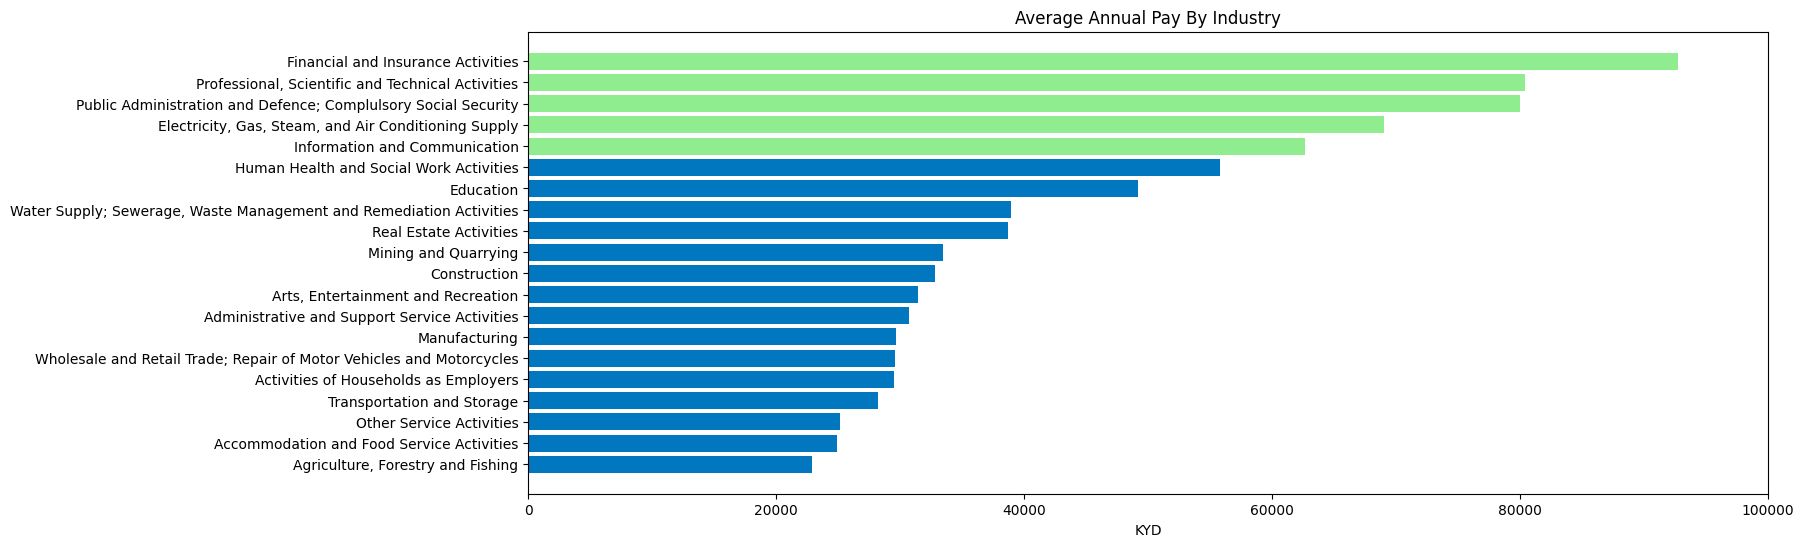

In [9]:
# Bar chart of the pay by industry
staging_df = pd.DataFrame(sorted_industry_averages)
sorted_df = staging_df.reset_index()
# Shorten excessivelly long name for label formatting
sorted_df["industry"] = sorted_df["industry"].apply(
    lambda val: "Activities of Households as Employers"
    if val.startswith("Activities") else val
)
# rank for coloring 
sorted_df["rank"] = sorted_df["mean_annual_salary"].rank(ascending=False)

# ranking added for coloring range - top five industries light green, all others light blue
sorted_df["colors"] = sorted_df["rank"].apply(
    lambda val: (.56, .93, .56) # light green
    if val <= 5 else (0, .467, .745) # light blue
)

# horizontal bar chart to show the average pay by industry
plt.figure(figsize=(16,6))
plt.title("Average Annual Pay By Industry")
plt.xlabel("KYD")
plt.barh(sorted_df["industry"], sorted_df["mean_annual_salary"], color=sorted_df["colors"]) # long lables therefore horizontal bar chart for readability
plt.xlim(0, 100000)
plt.gca().invert_yaxis() # greatest values shown at top
plt.show()


As Cayman is the #1 offshore fund domicile and #2 captive insurance domicile, it is not surprising that financial and insurance activities is the highest paying industry on average, with a mean average salary of $93k KYD. 

## Box and Whisker Plots for Distribution of Mean Annual Salary in Highest Paying Industries

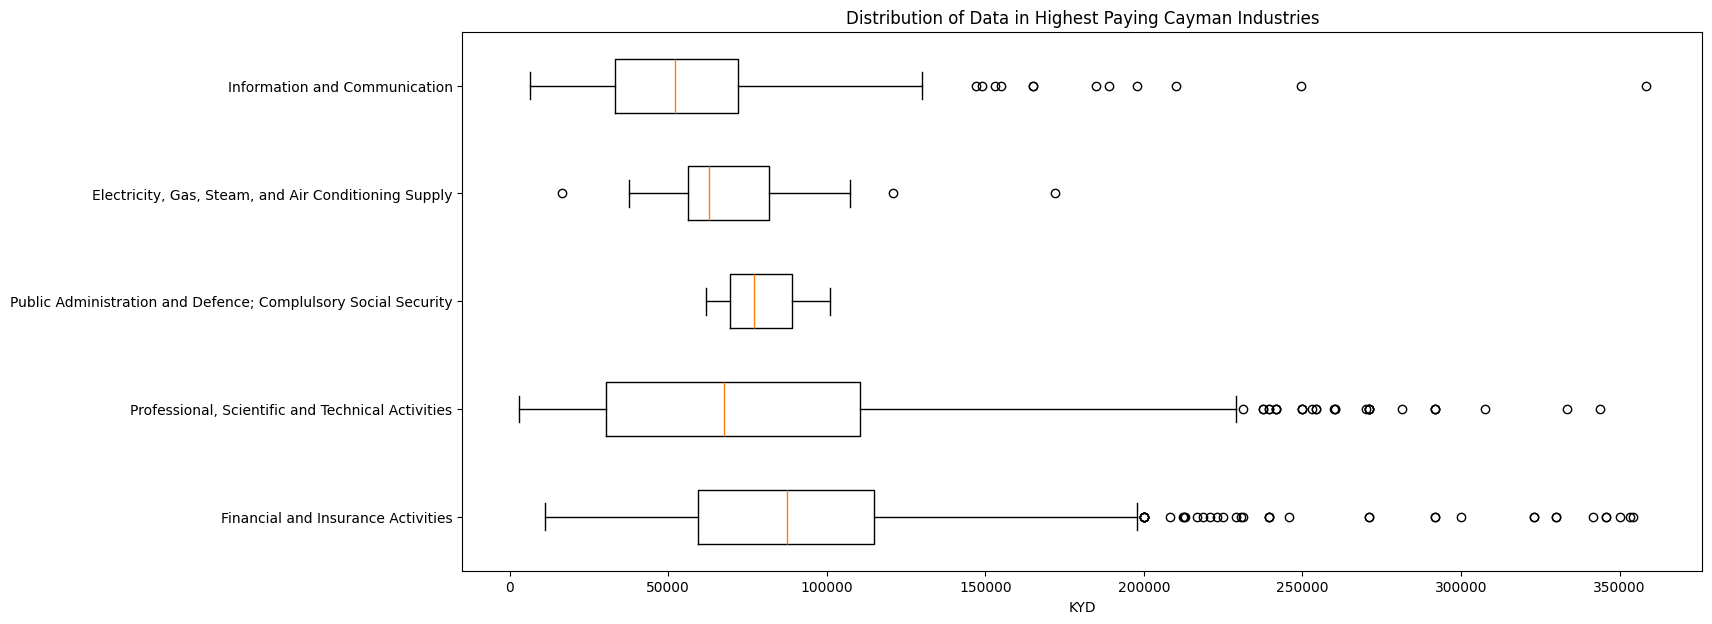

In [10]:
data = api_call("http://127.0.0.1:8000/jobs")
master_df = pd.DataFrame(data)

# define function for parsing the industry names to avoid hardcoded lengthy strings
def industry_parser(df: pd.DataFrame, industry_name: str) -> str:
        industry_str = df.loc[df["industry"].str.startswith(industry_name), "industry"].iloc[0]
        return industry_str


# Seperate the data set based on industry to create 5 dataframes for each of the highest paying industry
fi_str = industry_parser(master_df, "Financial")
fi_df = master_df[master_df["industry"]==fi_str]

pst_str = industry_parser(master_df, "Professional")
pst_df = master_df[master_df["industry"]==pst_str]

pad_str = industry_parser(master_df, "Public")
pad_df = master_df[master_df["industry"]==pad_str]

egs_str = industry_parser(master_df, "Electricity")
egs_df = master_df[master_df["industry"] == egs_str]

ic_str = industry_parser(master_df, "Information")
ic_df = master_df[master_df["industry"]==ic_str]

# create the box plot visualizations for the highest paying industries
plt.figure(figsize=(16, 7))
data = [
        fi_df["mean_annual_salary"], 
        pst_df["mean_annual_salary"], 
        pad_df["mean_annual_salary"], 
        egs_df["mean_annual_salary"], 
        ic_df["mean_annual_salary"]
]

box_labels = [
        fi_str, 
        pst_str, 
        pad_str, 
        egs_str, 
        ic_str
]

plt.boxplot(data, vert=False, tick_labels=box_labels)
plt.title("Distribution of Data in Highest Paying Cayman Industries")
plt.xlabel("KYD")
plt.show()


### Results
#### Overall 
All industries show a right-skewed distribution indicating a smaller number of high earners pulling the mean upward.
As outliers are promintent in every industry, this suggest that executive or highly specialized roles significantly exceed typical salaries.

#### Financial and Insurance Activites
Has the highest upper range across industries with outliers reaching 350k KYD, although the median is relatively high at 85-95k. The distribution of salaries suggests a highly stratified industry where there is a large gap between junior/senior roles and executives. 

#### Prossional, Scientific, and Technical Activities
Has the widest spread across the industries with significant high-end outliers. This could suggest diverse roles across subindustries and that pay varies heavily by specialization and experience. This is validated when examing the subindustries which indclude lawyers, auditors, architects, marketing, etc..

#### Public Administration and Defense
It is worth noting that this dataset only contains 3 data points for this industry, therefore, although the values appear relatively clustered, this sample size is insuffient to make any claims. 

#### Electricity, Gas, Steam, and Air Conditioning Supply
Moderate spread with median around 60-70k. Less extreme executive compensation compared to finance. 

#### Information and Communication
Moderate spread but with some notable outliers(360k). Most of the roles are moderately compensated but there are a few highly compensated positions(e.g. Senior IT or niche experts). This suggests an emerging or unevenly developed sector. 

#### Conclusion
Although finance and professional services have the strongest median salaries, there is high right-skew suggesting high inequality between junior and senior roles compared to executives. Examing the distribution of the information and communication industry suggests a developing industry that appears to have a few highly paid specialist/experts. EGS & AC has a more moderate spread with less extreme compensation compared to other high paying industries. Overall, the highest paying industries generally have right-skew with relatively extreme salaries at the upper end.

## Education on Salary and Regression for Years Experience 

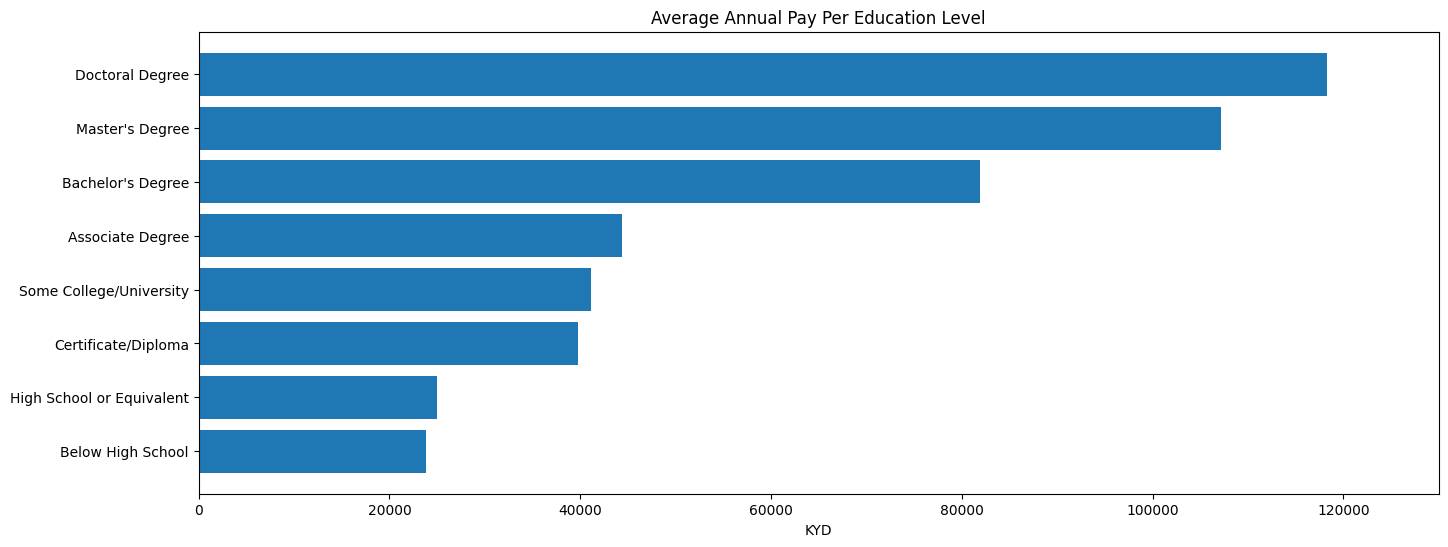

In [11]:
data = api_call("http://127.0.0.1:8000/jobs")
master_df = pd.DataFrame(data)

# plot education level and average salary
education_level_salary = master_df.groupby("education_level")["mean_annual_salary"].mean()
sorted_education = education_level_salary.sort_values(ascending=False)

plt.figure(figsize=(16,6))
plt.title("Average Annual Pay Per Education Level")
plt.xlabel("KYD")
plt.barh(sorted_education.index, sorted_education) 
plt.xlim(0, 130000)
plt.gca().invert_yaxis() # greatest values shown at top
plt.show()



As expected, salary increases with education level.

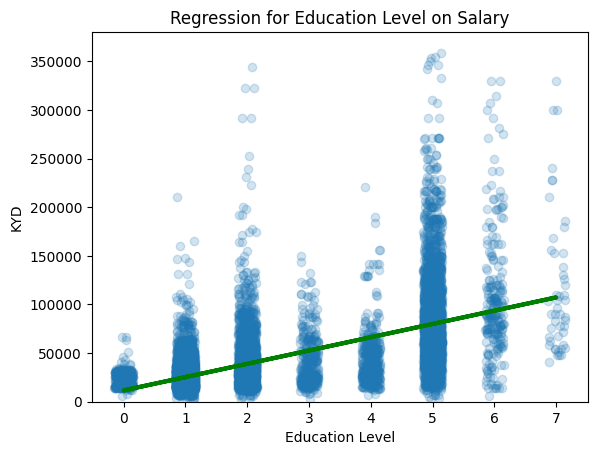

Coefficient: $13,659.07, Intercept: $11,666.15


In [12]:
# parse the years experience values, as it is a string value, to convert into numeric data
data = api_call("http://127.0.0.1:8000/jobs")
df = pd.DataFrame(data)

# use unique values of education levels to pass to ordinal encode for rankings
unique_education_levels = df["education_level"].unique()

education_levels = [
    "Below High School",
    "High School or Equivalent",
    "Certificate/Diploma",
    "Some College/University",
    "Associate Degree", 
    "Bachelor's Degree",
    "Master's Degree", 
    "Doctoral Degree"
 ]

# use ordinal encoding for the education categorical variable as there is an assumed inherent ranking
enc = OrdinalEncoder(categories=[education_levels])
df["education_encoded"] = enc.fit_transform(df[["education_level"]])

# perform the regression analysis
# initialize
X = np.array(df["education_encoded"]).reshape((-1, 1))
y = np.array(df["mean_annual_salary"])

# create the model
X_train, X_test, y_train, y_test = train_test_split(X, y)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# jitter the scatter plot for visualization purposes
def add_jitter(x: np.ndarray, amount: float) -> np.ndarray:
    return x + np.random.uniform(-amount, amount, size=len(x))

# plotting 
plt.title("Regression for Education Level on Salary")
plt.xlabel("Education Level")
plt.ylabel("KYD")
plt.ylim(0, 380000)
plt.scatter(add_jitter(X.flatten(), .15), y, alpha=0.2) # flatten as X is a 2 dimensional array and the jittering/plotting expecting 1D
plt.plot(X_test, y_pred, c="g", linewidth="3")
plt.show()

print(f"Coefficient: ${model.coef_[0]:,.2f}, Intercept: ${model.intercept_:,.2f}")



The regression above has been plotted for uses ordinal encoding which assumes that there is a linear increase in the levels of education for pay. This is likely an unrealistic assumption. Though the fitted line suggests a positive relationship whereby salary increases with education level, the true relationship may be non-linear e.e.g the jump between associates and bachelor's may not be equal to the jump between bachelor's and master's. Further analysis is recommended before making any claims based on the above. 

### Results

It is observed that salary generally increases for the level of education. Although, it should be further explored how this varies across industries. The regression analysis above suggests a positive relationship but further analyis is required to investigate the effect per level of education level, as the above analysis currently assumes an equal increase between levels which is unlikely to be true. 

## Conclusion

Considering Cayman's status as the global #1 and #2 domicile for funds and captive insurance respectively, it is unsurprising that the highest paying industry is Financial and Insurance activities. When investigating how salaries are distributed across the highest paying industries, they are right-skewed, suggesting that there is a large gap between the executive salaries and junior/senior positions. Education appears to have a positive effect on salary, although further analysis should be conducted to determine the effect each education level has. 

The data analysis performed above demonstrates the utility of the REST API and database which has been created on the WORC job listing data. By making this data accessible over the web with HTTP, the data can be used in programming workflows such as data analysis, etc.. 